In [1]:
import pandas as pd

df = pd.read_csv("car data.csv")

In [2]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
df.shape

(301, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [5]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


In [6]:
df.duplicated().sum()

np.int64(2)

In [7]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (299, 9)


In [8]:
df[df.duplicated()]

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.shape

(299, 9)

In [11]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,299.000000,299.000000,299.000000,299.000000,299.000000
mean,2013.615385,4.589632,7.541037,36916.752508,0.043478
std,2.896868,4.984240,8.566332,39015.170352,0.248720
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.850000,1.200000,15000.000000,0.000000
50%,2014.000000,3.510000,6.100000,32000.000000,0.000000
75%,2016.000000,6.000000,9.840000,48883.500000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [12]:
df["Fuel_Type"].value_counts()

,count
Fuel_Type,
Petrol,239
Diesel,58
CNG,2


In [13]:
df["Selling_type"].value_counts()

,count
Selling_type,
Dealer,193
Individual,106


In [14]:
df["Transmission"].value_counts()

,count
Transmission,
Manual,260
Automatic,39


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

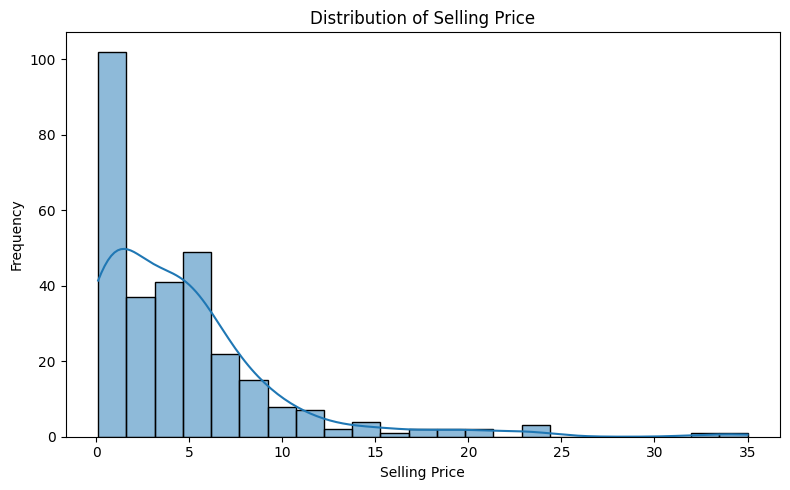

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Selling_Price"], kde=True)
plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

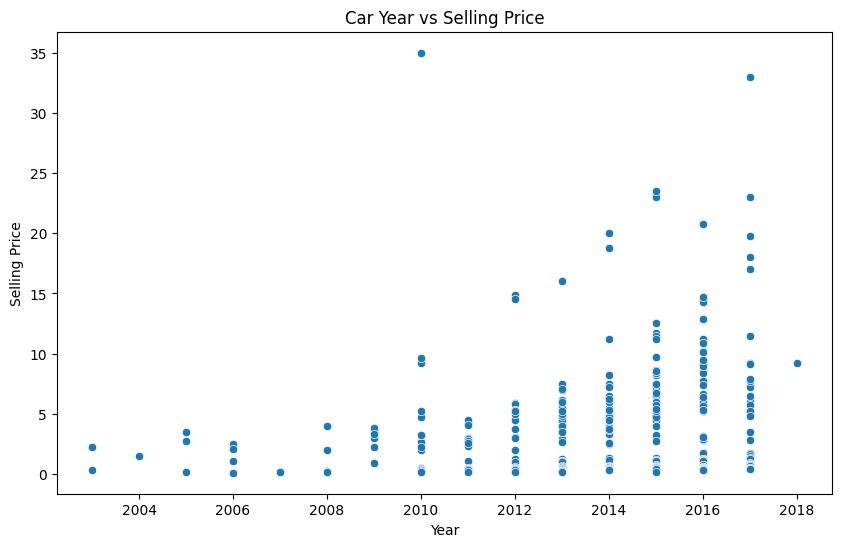

In [17]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Year",
    y="Selling_Price"
)

plt.title("Car Year vs Selling Price")
plt.xlabel("Year")
plt.ylabel("Selling Price")
plt.show()

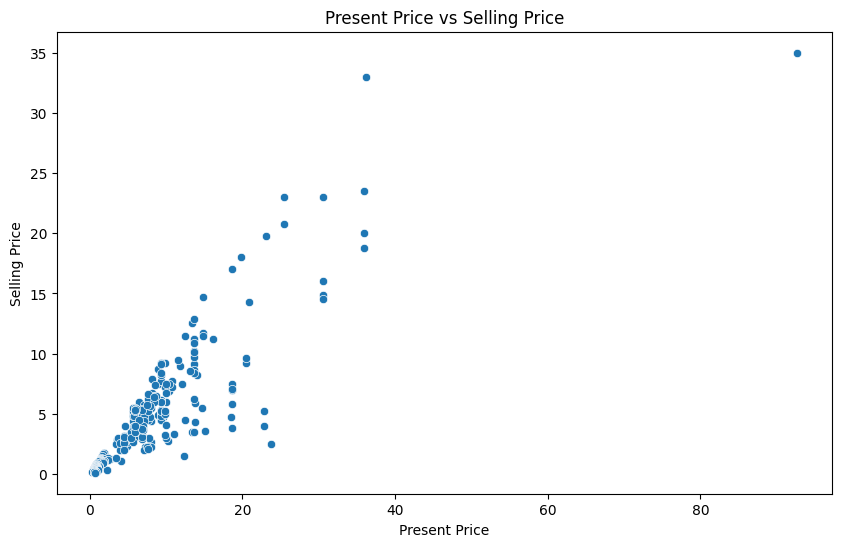

In [18]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Present_Price",
    y="Selling_Price"
)

plt.title("Present Price vs Selling Price")
plt.xlabel("Present Price")
plt.ylabel("Selling Price")

plt.show()

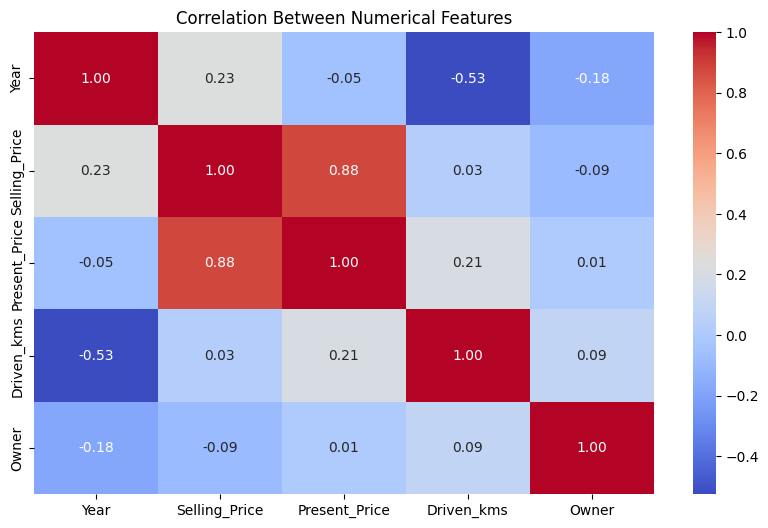

In [19]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Numerical Features")
plt.show()

In [20]:
df["Car_Age"] = 2026 - df["Year"]

df[["Year", "Car_Age"]].head()

,Year,Car_Age
0,2014,12
1,2013,13
2,2017,9
3,2011,15
4,2014,12


In [21]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Car_Age'],
      dtype='object')

In [22]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0
Car_Age,0


In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df.select_dtypes(include="object").columns

Index(['Car_Name', 'Fuel_Type', 'Selling_type', 'Transmission'], dtype='object')

In [25]:
for col in ["Fuel_Type", "Selling_type", "Transmission"]:
    print(col)
    print(df[col].value_counts())
    print()

Fuel_Type
Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64

Selling_type
Selling_type
Dealer        193
Individual    106
Name: count, dtype: int64

Transmission
Transmission
Manual       260
Automatic     39
Name: count, dtype: int64



In [26]:
df_model = df.drop("Car_Name", axis=1)

df_model = pd.get_dummies(
    df_model,
    columns=["Fuel_Type", "Selling_type", "Transmission"],
    drop_first=True
)

df_model.head()

,Year,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,2014,3.35,5.59,27000,0,12,False,True,False,True
1,2013,4.75,9.54,43000,0,13,True,False,False,True
2,2017,7.25,9.85,6900,0,9,False,True,False,True
3,2011,2.85,4.15,5200,0,15,False,True,False,True
4,2014,4.60,6.87,42450,0,12,True,False,False,True


In [27]:
X = df_model.drop("Selling_Price", axis=1)
y = df_model["Selling_Price"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (299, 9)
y shape: (299,)


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (239, 9)
X_test: (60, 9)
y_train: (239,)
y_test: (60,)


In [29]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [30]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[ 7.50049519  7.791134    1.36525272  7.00895369 11.16501084  4.53381705
  8.49154086  1.69915065  8.82263182 -0.96326043]


In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 1.4725457508177955
MSE: 6.373125106259817
R2 Score: 0.7527233824220831


In [32]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest model training completed!")

Random Forest model training completed!


In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest MSE:", rf_mse)
print("Random Forest R2 Score:", rf_r2)

Random Forest MAE: 1.3710977815613865
Random Forest MSE: 10.088718675966057
Random Forest R2 Score: 0.6085587230293508


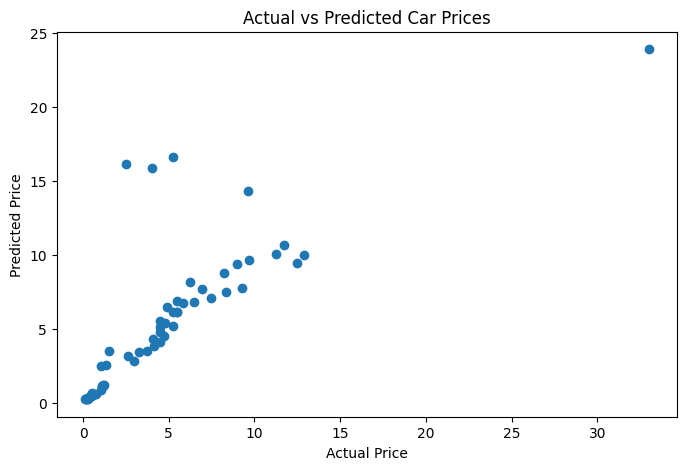

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

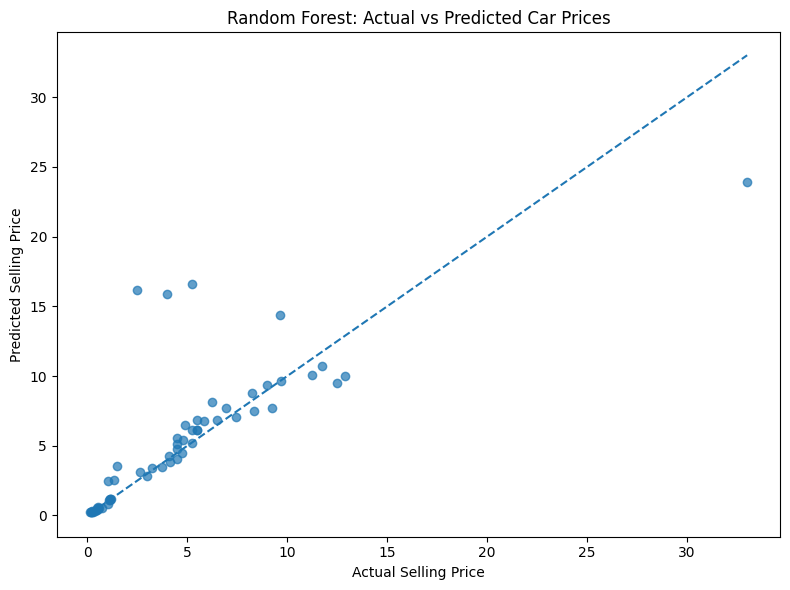

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, rf_pred, alpha=0.7)

min_value = min(y_test.min(), rf_pred.min())
max_value = max(y_test.max(), rf_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Random Forest: Actual vs Predicted Car Prices")

plt.tight_layout()
plt.show()

In [36]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

Present_Price              9.250204e-01
Year                       3.116517e-02
Car_Age                    2.703051e-02
Driven_kms                 1.051775e-02
Transmission_Manual        2.730819e-03
Selling_type_Individual    2.333418e-03
Fuel_Type_Diesel           6.840441e-04
Fuel_Type_Petrol           5.177331e-04
Owner                      1.833532e-07
dtype: float64


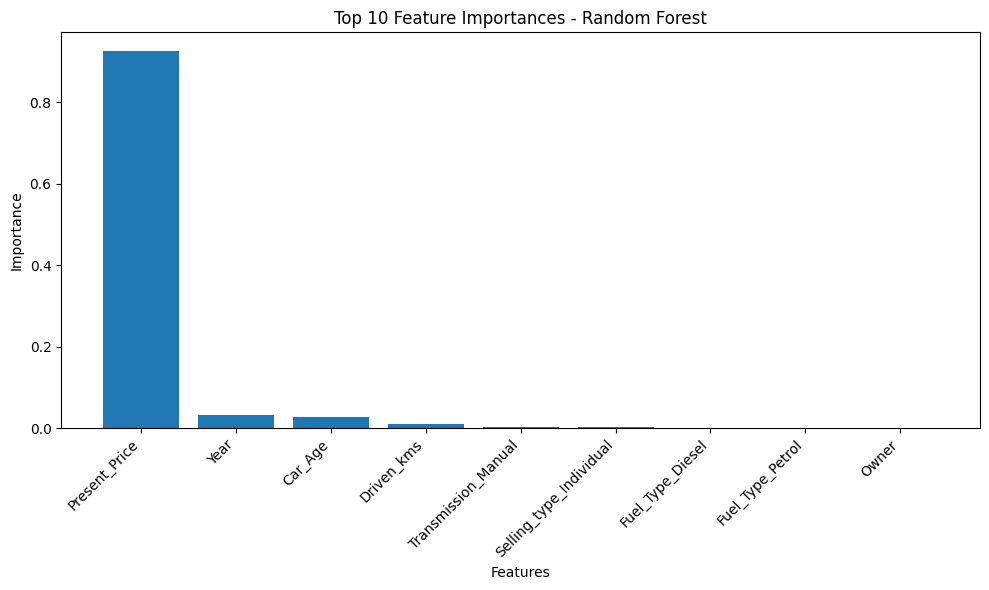

In [37]:
# Top 10 Feature Importance
top_10 = feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.bar(top_10.index, top_10.values)

plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

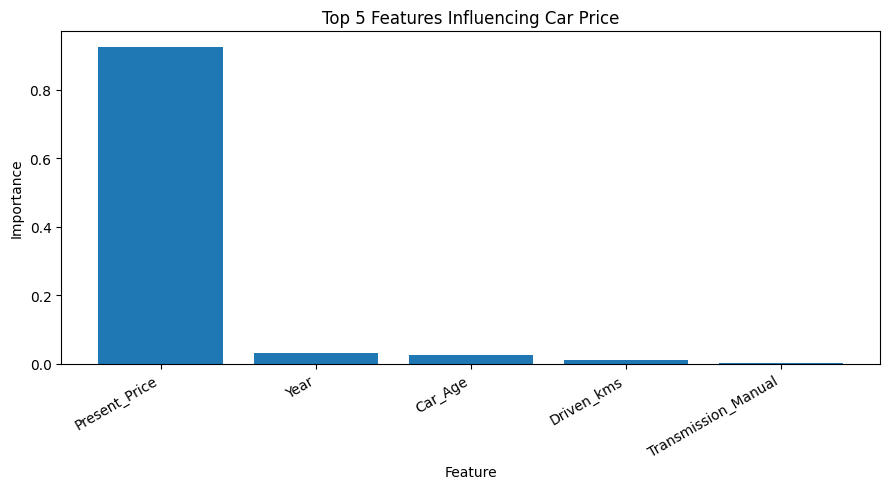

In [38]:
top_features = feature_importance.head(5)

plt.figure(figsize=(9, 5))
plt.bar(top_features.index, top_features.values)

plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Top 5 Features Influencing Car Price")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("------------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Model Evaluation Results
------------------------
MAE : 1.4725457508177955
MSE : 6.373125106259817
RMSE: 2.5245049230016994
R²  : 0.7527233824220831


In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, rf_pred)
mse = mean_squared_error(y_test, rf_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, rf_pred)

print("Random Forest Evaluation Results")
print("--------------------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Random Forest Evaluation Results
--------------------------------
MAE : 1.3710977815613865
MSE : 10.088718675966057
RMSE: 3.1762743389017984
R²  : 0.6085587230293508


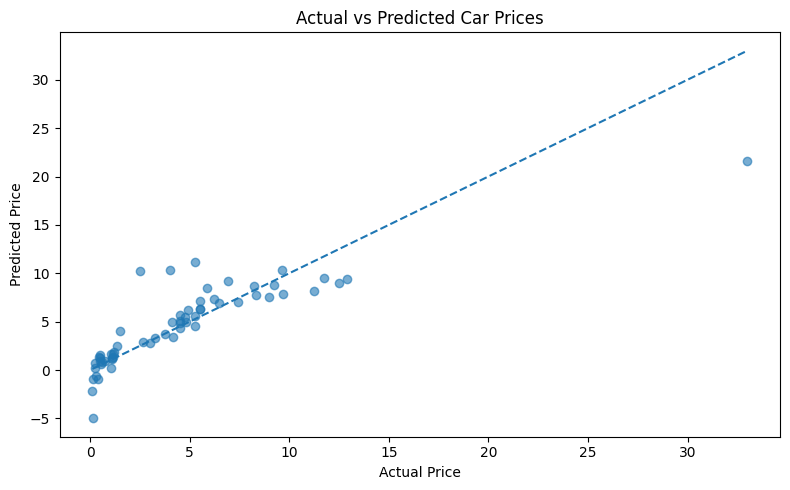

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.tight_layout()
plt.show()

In [42]:
import pandas as pd

comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison["Difference"] = (
    comparison["Actual Price"] - comparison["Predicted Price"]
)

comparison.head(10)

,Actual Price,Predicted Price,Difference
0,8.99,7.500495,1.489505
1,8.35,7.791134,0.558866
2,0.45,1.365253,-0.915253
3,7.45,7.008954,0.441046
4,5.25,11.165011,-5.915011
5,5.25,4.533817,0.716183
6,5.85,8.491541,-2.641541
7,1.15,1.699151,-0.549151
8,9.25,8.822632,0.427368
9,0.38,-0.963260,1.343260


## Conclusion

The Car Price Prediction project demonstrates how machine learning can be used to predict used car selling prices based on features such as present price, year, car age, driven kilometers, owner, fuel type, selling type, and transmission.

Two regression models were evaluated: Linear Regression and Random Forest Regression. Linear Regression achieved an R² score of approximately 0.753, while Random Forest achieved an R² score of approximately 0.6086 on the test data.

Based on the evaluation results, Linear Regression performed better than Random Forest for this dataset.

The Random Forest feature importance analysis showed that Present Price was the most influential feature, followed by Year, Car Age, and Driven Kilometers.

Overall, the project demonstrates the complete machine learning workflow, including data preprocessing, feature engineering, model training, prediction, evaluation, and feature importance analysis.
